<a href="https://colab.research.google.com/github/armankhatamsaz/ModelFitting-Classification-Techniques/blob/main/ModelFitting_Classification_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Model fitting and classification**

**Part 1 – Model fitting for continuous distributions: Multivariate Gaussian**

In this Part, we will employ a dataset based on the classic dataset *Iris Plants Database* https://archive.ics.uci.edu/ml/datasets/iris. You will be provided a subset of this dataset comprising only two classes (*Iris Setosa* and *Iris Versicolour*), and only two features per class (*petal length* in cm and *petal width* in cm). The objective is to the determine the kind of iris based on the content of the features.

**Task:** we have to fit class-conditional Gaussian multivariate distributions to the data, and visualize the probability density functions. In particular, you should perform the following:


*   Divide the dataset in two parts (*Iris Setosa* which corresponds to class zero and *Iris Versicolour* which correspond to class 1). Then work only on one class at a time.
*   Plot the data of each class (use the *plt.scatter( )* function)
*   Visualize the histogram of petal length and petal width (use e.g. the *plt.hist( )* function)
*   Calculate the maximum likelihood estimate of the mean and covariance matrix under a multivariate Gaussian model, independently for each class (these are the parameters of the class-conditional distributions). Note: is the Gaussian model good for these data?
*    Visualize the 2-D joint pdf of petal length and width for the two classes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

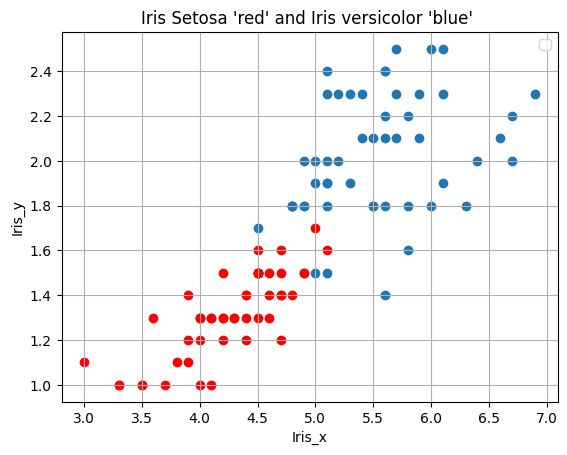

In [ ]:
Dataset1 = h5py.File("/content/Lab2_Ex_1_Iris.hdf5")
Data = np.array(Dataset1.get('Dataset'))

#Separate the dataset in the two classes, you can use the numpy function argsort and unique to do this.
Iris_Setosa=[]
Iris_Versicolor=[]
for i in range(len(Data)):
    if Data[i, 2] == 0:
        Iris_Setosa.append(Data[i])
    else:
        Iris_Versicolor.append(Data[i])
Iris_Setosa_array=np.array(Iris_Setosa)
Iris_Versicolor_array=np.array(Iris_Versicolor)
#Draw the scatter plot of the two classes on the same image
plt.scatter(Iris_Setosa_array[:,0],Iris_Setosa_array[:,1],color="r")
plt.scatter(Iris_Versicolor_array[:,0],Iris_Versicolor_array[:,1])
plt.xlabel("Iris_x")
plt.ylabel("Iris_y")
plt.title("Iris Setosa 'red' and Iris versicolor 'blue' ")
plt.legend()
plt.grid()
plt.show()

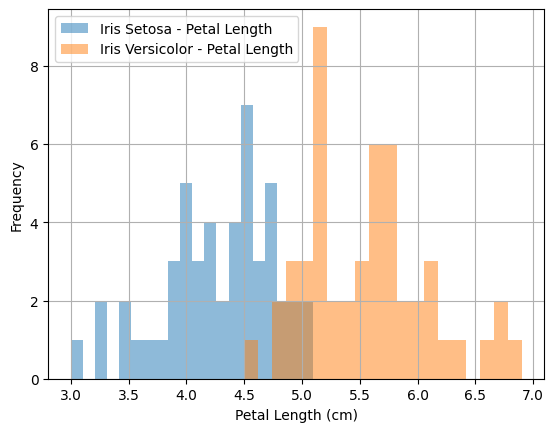

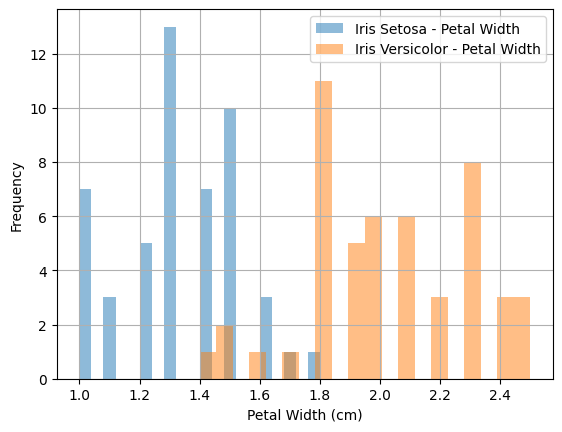

In [ ]:
#Visualize the histogram of petal length and petal width (use e.g. the plt.hist() function)

plt.hist(Iris_Setosa_array[:, 0], bins=20, alpha=0.5, label='Iris Setosa - Petal Length')
plt.hist(Iris_Versicolor_array[:, 0], bins=20, alpha=0.5, label='Iris Versicolor - Petal Length')

plt.xlabel("Petal Length (cm)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()


plt.hist(Iris_Setosa_array[:, 1], bins=20, alpha=0.5, label='Iris Setosa - Petal Width')
plt.hist(Iris_Versicolor_array[:, 1], bins=20, alpha=0.5, label='Iris Versicolor - Petal Width')

plt.xlabel("Petal Width (cm)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()


In [ ]:
#Calculate mean and covariance matrix under a multivariate Gaussian model. Scalar products can be computed with the function np.matmul()

# Function to calculate the mean
def calculate_mean(data):
    return np.mean(data, axis=0)

#The transpose can be obtained with the function np.transpose
# Function to calculate the covariance matrix
def calculate_covariance(data, mean):
    # Center the data (subtract the mean)
    centered_data = data - mean
    # Now, calculate the covariance matrix using np.transpose for matrix multiplication
    covariance_matrix = np.matmul(centered_data.T, centered_data) / (data.shape[0] - 1)
    return covariance_matrix

#To make a scalar product between arrays in the form [Mx1]x[1xM] starting from 1D array A it may be necessary to add a new axis using
#the function A[:,np.newaxis]
# Calculate mean and covariance for Setosa
setosa_mean = calculate_mean(Iris_Setosa_array)
setosa_cov = calculate_covariance(Iris_Setosa_array, setosa_mean)

# Calculate mean and covariance for Versicolor
versicolor_mean = calculate_mean(Iris_Versicolor_array)
versicolor_cov = calculate_covariance(Iris_Versicolor_array, versicolor_mean)

# Regularization: Adding a small value to the diagonal elements of covariance to prevent singularity
regularization_term = 1e-6
setosa_cov += np.eye(setosa_cov.shape[0]) * regularization_term
versicolor_cov += np.eye(versicolor_cov.shape[0]) * regularization_term

# Print the results
print("Maximum Likelihood Estimate for Iris Setosa:")
print("Mean (Petal Length, Petal Width):", setosa_mean)
print("Covariance Matrix:\n", setosa_cov)

print("\nMaximum Likelihood Estimate for Iris Versicolor:")
print("Mean (Petal Length, Petal Width):", versicolor_mean)
print("Covariance Matrix:\n", versicolor_cov)


Maximum Likelihood Estimate for Iris Setosa:
Mean (Petal Length, Petal Width): [4.26  1.326 0.   ]
Covariance Matrix:
 [[2.20817327e-01 7.31020408e-02 0.00000000e+00]
 [7.31020408e-02 3.91071224e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e-06]]

Maximum Likelihood Estimate for Iris Versicolor:
Mean (Petal Length, Petal Width): [5.552 2.026 1.   ]
Covariance Matrix:
 [[3.04588755e-01 4.88244898e-02 0.00000000e+00]
 [4.88244898e-02 7.54336531e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e-06]]


**To answer that question " is the Gaussian model good for these data? "**


The Gaussian model is a reasonable fit for the data, but the covariance matrices show small values indicating that some regularization was needed. This suggests that while the data may follow a Gaussian distribution, there may be dependencies or issues in the data that require further exploration or refinement of the model.



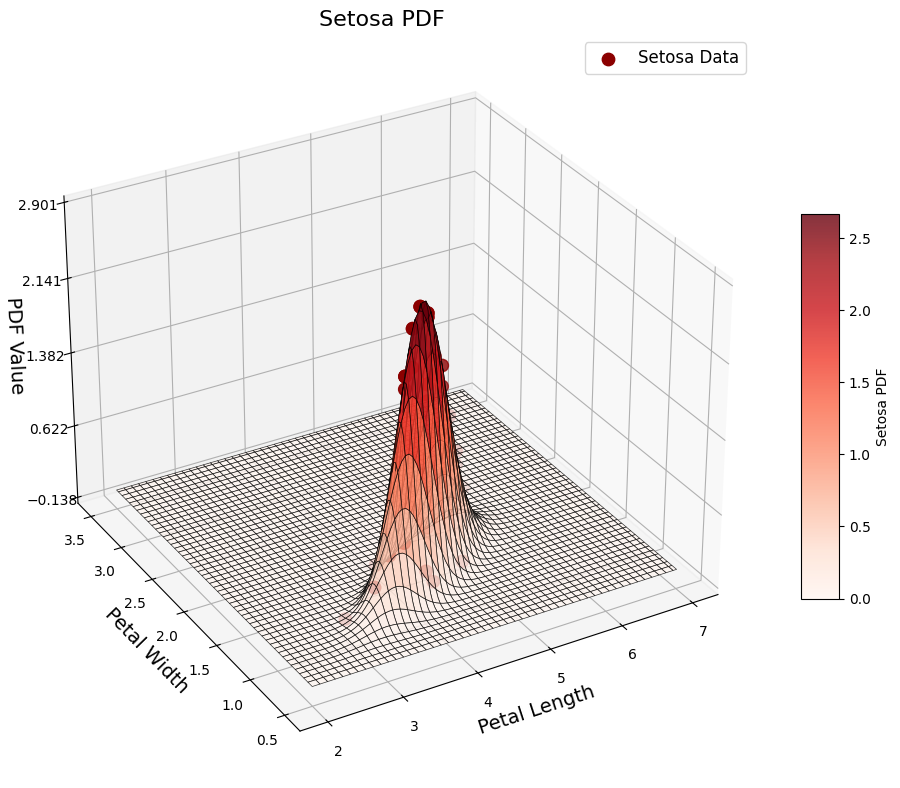

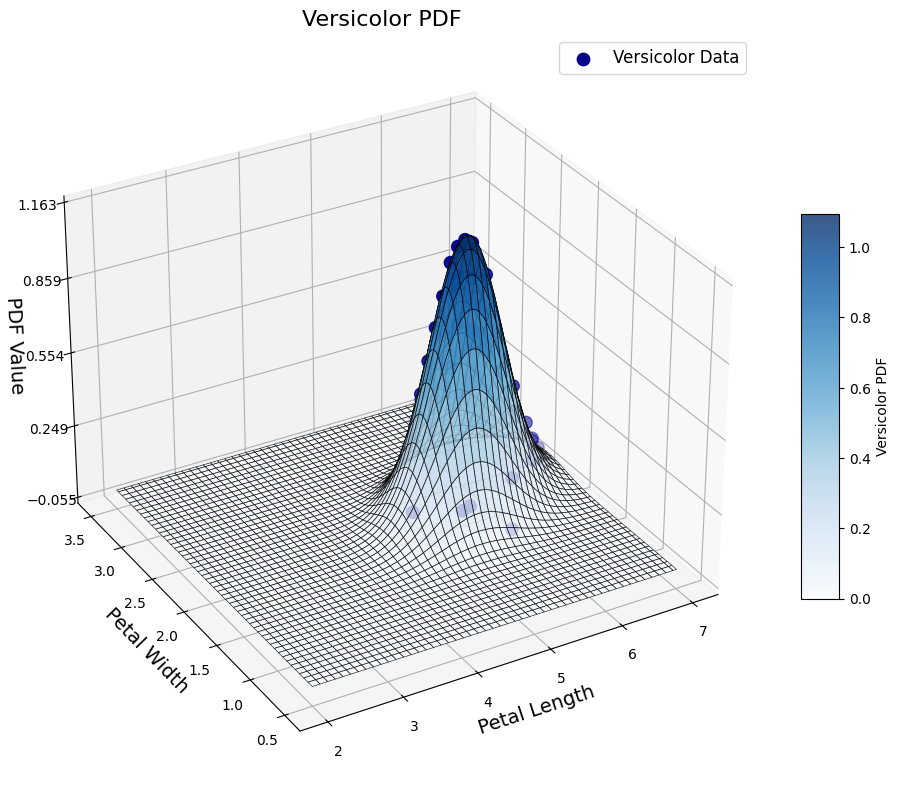

In [ ]:
#Visualize the 2-D joint pdf of petal length and width, a pdf function can be initialized by providing mean and covariance matrix

from scipy.stats import multivariate_normal
from matplotlib import cm
from matplotlib.ticker import LinearLocator

# Precomputed means and covariance matrices
mean_setosa = setosa_mean[:2]  # Select only length and width
cov_setosa = setosa_cov[:2, :2]  # Select 2x2 covariance matrix

mean_versicolor = versicolor_mean[:2]  # Select only length and width
cov_versicolor = versicolor_cov[:2, :2]  # Select 2x2 covariance matrix

# Data points for Setosa and Versicolor (ensure they only include length and width)
setosa_data = Iris_Setosa_array[:, :2]
versicolor_data = Iris_Versicolor_array[:, :2]


# Step 1: Create a grid
x = np.linspace(2, 7, 100)
y = np.linspace(0.5, 3.5, 100)
X, Y = np.meshgrid(x, y)

# Flatten the grid for PDF calculation
XY = np.vstack([X.ravel(), Y.ravel()]).T

# Calculate PDFs
pdf_setosa = multivariate_normal(mean=mean_setosa, cov=cov_setosa).pdf(XY).reshape(X.shape)
pdf_versicolor = multivariate_normal(mean=mean_versicolor, cov=cov_versicolor).pdf(XY).reshape(X.shape)

# Plot for Setosa
fig_setosa = plt.figure(figsize=(12, 10))
ax_setosa = fig_setosa.add_subplot(111, projection='3d')

# Surface plot for Setosa
surface_setosa = ax_setosa.plot_surface(X, Y, pdf_setosa, cmap=cm.Reds, alpha=0.8, edgecolor='k', linewidth=0.5)
ax_setosa.scatter(setosa_data[:, 0], setosa_data[:, 1], multivariate_normal(mean=mean_setosa, cov=cov_setosa).pdf(setosa_data), color='darkred', s=80, label='Setosa Data')

# Add labels and adjust axis
ax_setosa.set_xlabel('Petal Length', fontsize=14)
ax_setosa.set_ylabel('Petal Width', fontsize=14)
ax_setosa.set_zlabel('PDF Value', fontsize=14)
ax_setosa.set_title('Setosa PDF', fontsize=16)
ax_setosa.legend(loc='upper right', fontsize=12)
ax_setosa.zaxis.set_major_locator(LinearLocator(5))
fig_setosa.colorbar(surface_setosa, ax=ax_setosa, shrink=0.5, aspect=10, label='Setosa PDF')

# Adjust view angle
ax_setosa.view_init(30, 240)

# Plot for Versicolor
fig_versicolor = plt.figure(figsize=(12, 10))
ax_versicolor = fig_versicolor.add_subplot(111, projection='3d')

# Surface plot for Versicolor
surface_versicolor = ax_versicolor.plot_surface(X, Y, pdf_versicolor, cmap=cm.Blues, alpha=0.8, edgecolor='k', linewidth=0.5)
ax_versicolor.scatter(versicolor_data[:, 0], versicolor_data[:, 1], multivariate_normal(mean=mean_versicolor, cov=cov_versicolor).pdf(versicolor_data), color='darkblue', s=80, label='Versicolor Data')

# Add labels and adjust axis
ax_versicolor.set_xlabel('Petal Length', fontsize=14)
ax_versicolor.set_ylabel('Petal Width', fontsize=14)
ax_versicolor.set_zlabel('PDF Value', fontsize=14)
ax_versicolor.set_title('Versicolor PDF', fontsize=16)
ax_versicolor.legend(loc='upper right', fontsize=12)
ax_versicolor.zaxis.set_major_locator(LinearLocator(5))
fig_versicolor.colorbar(surface_versicolor, ax=ax_versicolor, shrink=0.5, aspect=10, label='Versicolor PDF')

# Adjust view angle
ax_versicolor.view_init(30, 240)

plt.show()




**Part 2 - Model fitting for discrete distributions: Bag of Words**


In this Part, we will employ a real dataset (file *SMSSpamCollection*). The SMS Spam Collection v.1 (https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) is a set of SMS tagged messages that have been collected for SMS Spam research. It contains one set of SMS messages in English of 5,574 messages, tagged acording being ham (legitimate) or spam.
Task: we have to fit the parameters employed by a Naïve Bayes Classifier, using a Bernoulli model. Under this model, the parameters are:

*   $\pi_{c}$, the prior probabilities of each class.
*   $\theta_{jc}$, the probability that feature j is equal to 1 in class c.

Model fitting can be done using the pseudocode at the end of the Lecture 3 slides.

Display the class-conditional densities $\theta_{jc1}$ and $\theta_{jc2}$. Try to identify “uninformative” features (i.e., features j such that $\theta_{jc1}$ ≃ $\theta_{jc2}$).

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# reading the data
data = pd.read_csv("SMSSpamCollection", encoding="ISO-8859-1", sep="\t", header=None)
data.rename(columns={0: "labels", 1: "text"}, inplace=True)
display(data)

# Transform data to bag of word representation
bagger = CountVectorizer(
    max_features=2500,
    binary=True,  # Bernulli Model
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)
bag = bagger.fit_transform(data["text"]).toarray() #Fits the vectorizer to the text data and transforms each SMS
                                                   #message into a binary vector.
feature_names = bagger.get_feature_names_out()

data = pd.concat([data, pd.DataFrame(bag, columns=feature_names)], axis=1)
display(data)

X_train = data.iloc[:2000,2:].to_numpy()
X_test = data.iloc[2000:3000,2:].to_numpy()
y_train = data.iloc[:2000,0].to_numpy() == 'ham' # Converts the labels into boolean values,where True means the message
                                                 # is "ham" (not spam) and False means it is "spam".
y_test = data.iloc[2000:3000,0].to_numpy() == 'ham'

,labels,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ã¼ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


,labels,text,aah,aathi,abi,abiola,able,about,abt,abta,...,you,your,yours,yourself,yr,yrs,yummy,yun,yup,zed
0,ham,"Go until jurong point, crazy.. Available only ...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ham,Ok lar... Joking wif u oni...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ham,U dun say so early hor... U c already then say...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5568,ham,Will Ã¼ b going to esplanade fr home?,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5570,ham,The guy did some bitching but I acted like i'd...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive') #allows Google Colab to interact with Google Drive.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Evaluate the probabilities of the two classes (πc)
pi_spam = np.mean(~y_train)  # Probability of spam class
pi_ham = np.mean(y_train)   # Probability of ham class

# Calculate class-conditional densities (θjc)
theta_spam = np.mean(X_train[~y_train], axis=0)  # θjc for spam class
theta_ham = np.mean(X_train[y_train], axis=0)    # θjc for ham class

# Display prior probabilities
print("Prior Probabilities (πc):")
print(f"π_spam: {pi_spam:.4f}")
print(f"π_ham: {pi_ham:.4f}")

Prior Probabilities (πc):
π_spam: 0.1400
π_ham: 0.8600



Top Uninformative Features:
     Feature  θjc_spam   θjc_ham  Difference
2185      to  0.632143  0.255814    0.376329
301     call  0.410714  0.048837    0.361877
2242     txt  0.246429  0.004070    0.242359
776     free  0.239286  0.009302    0.229983
1494      or  0.246429  0.050000    0.196429
2491    your  0.264286  0.081395    0.182890
1449     now  0.246429  0.065698    0.180731
392    claim  0.157143  0.000000    0.157143
2278      ur  0.189286  0.037791    0.151495
2458     www  0.142857  0.000000    0.142857
792     from  0.160714  0.027907    0.132807
762      for  0.225000  0.094767    0.130233
2118    text  0.132143  0.015698    0.116445
1346  mobile  0.117857  0.001744    0.116113
1741   reply  0.125000  0.011628    0.113372
1393      my  0.021429  0.131977    0.110548
1296      me  0.025000  0.134302    0.109302
1639   prize  0.107143  0.000000    0.107143
1506     our  0.117857  0.012209    0.105648
2019    stop  0.110714  0.006395    0.104319


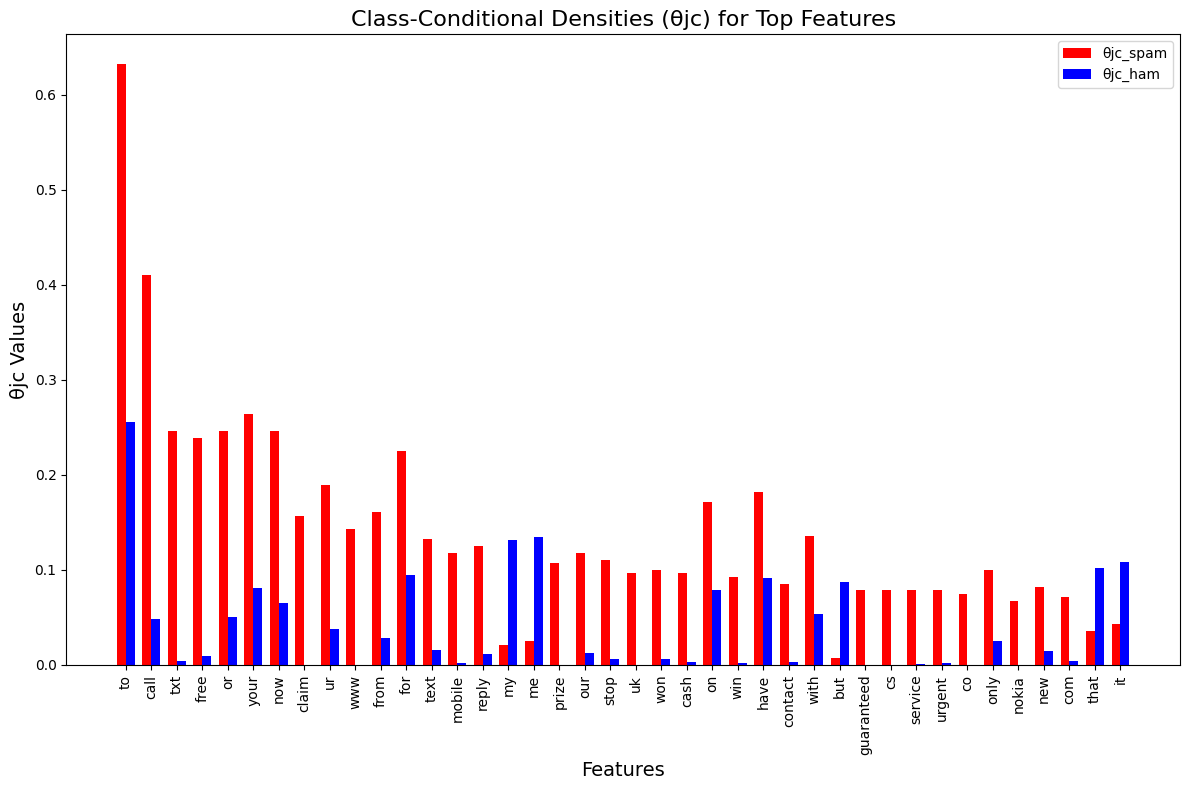

     Feature  θjc_spam   θjc_ham  Difference
2185      to  0.632143  0.255814    0.376329
301     call  0.410714  0.048837    0.361877
2242     txt  0.246429  0.004070    0.242359
776     free  0.239286  0.009302    0.229983
1494      or  0.246429  0.050000    0.196429
...      ...       ...       ...         ...
1064   issue  0.000000  0.000000    0.000000
1065  issues  0.000000  0.000000    0.000000
1072      iz  0.000000  0.000000    0.000000
2182      tm  0.000000  0.000000    0.000000
1250  luxury  0.000000  0.000000    0.000000

[2500 rows x 4 columns]


In [ ]:
# Create a DataFrame for θjc values and their differences
theta_df = pd.DataFrame({
    "Feature": feature_names,
    "θjc_spam": theta_spam,
    "θjc_ham": theta_ham,
    "Difference": np.abs(theta_spam - theta_ham)  # Difference to identify uninformative features
})

# Sort by difference in descending order to get the most informative features
theta_df = theta_df.sort_values(by="Difference", ascending=False)


# Display top uninformative features
print("\nTop Uninformative Features:")
print(theta_df.head(20))

# Display top features
top_features = theta_df.head(40)  # Display top 50 features for better visualization

plt.figure(figsize=(12, 8))
bar_width = 0.35
index = np.arange(len(top_features))

# Plot θjc values for spam and ham
plt.bar(index, top_features["θjc_spam"], bar_width, label="θjc_spam", color="red")
plt.bar(index + bar_width, top_features["θjc_ham"], bar_width, label="θjc_ham", color="blue")

plt.xlabel("Features", fontsize=14)
plt.ylabel("θjc Values", fontsize=14)
plt.title("Class-Conditional Densities (θjc) for Top Features", fontsize=16)
plt.xticks(index + bar_width / 2, top_features["Feature"], rotation=90, fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

# Display θjc values and differences for debugging
print(theta_df)



**Comments to Part 2**

In this analysis, we observed that words with similar probabilities in both spam (
θ
jc_spam
​
 ) and ham (
θ
jc_ham
​
 ) classes, such as "to," are uninformative features. These words appear frequently in both types of messages and thus do not contribute significantly to distinguishing spam from ham. On the other hand, words like "prize," which have a high probability in spam messages (
θ
jc_spam
​
 ) and a near-zero probability in ham messages (
θ
jc_ham
​
 ), are highly informative features. These words are strong indicators of spam and are crucial for building effective classification models like Naïve Bayes. Identifying and leveraging such informative features is key to improving spam detection accuracy.

**Part 3 - Classification – discrete data**

In this Part, we will design a Naïve Bayes Classifier (NBC) for the Bag of Words (BoW) features for document classification that have been prepared in *Exercise 2*. In particular, in *exercise 2*, you have already estimated the following parameters:


*   The prior probabilities of each class, $\pi_{c} = p(y=c)$.
*   The class-conditional probabilities of each feature, $\theta_{jc} = p(x_{j}=1 | y=c)$.

These parameters have been estimated from the training data. In this exercise, you will use the test data, and classify each test vector using an NBC whose model has been fitted in *Exercise 2*. In particular, you will do the following:



*   For each test vector, calculate the MAP estimate of the class the test vector belongs to. Remember: the MAP classifier chooses the class that maximizes $\mathop{\max\limits_c{\log p(y=c|x)} \propto \log p(x|y=c)} + \log p(c)$. In the NBC, the features (i.e. each entry of $x$) are assumed to be statistically independent, so $p(x|y=c) = \prod_{j=1}^{D}p(x_{j}|y=c)$. This formula allows you to calculate $p(x|y=c)$ for a given test vector $x$ using the parameters $\theta_{jc}$ already calculated in *Exercise 2*. Note that, after the logarithm, the product
becomes a summation. It is much better to use the logarithm in order to avoid underflow.
*   See how the accuracy changes when the prior is not taken into account (e.g. by comparing the MLE and MAP estimate).
*   After classifying a test vector using the NBC, the obtained class can be compared with the truth (vector *ytest*).
*   The accuracy of the classifier can be computed as the percentage of times that the NBC provides the correct class for a test vector.
*   Repeat the same operations using the training data as test data, and compare the accuracy of the classifier on the training and test data.
*   Note: It is expected that students implement the Naive Bayes classifier from scratch without using pre-made functions such as sklearn.naive_bayes

**Optional:**

If you plot the class-conditional densities as done at the end of Exercise 2, you will see that many features are uninformative; e.g., words that appear very often (or very rarely) in documents belonging to either class are not very helpful to classify a document. The NBC can perform a lot better if these uninformative features are disregarded during the classification, i.e. only a subset of the features, chosen among the most informative ones, are retained. To rank the features by “significance”, one can employ the mutual information between feature $x_{j}$ and class $y$ (see Sec. 3.5.4 of the textbook):

\begin{align*}
I(X,Y) = \sum_{xj} \sum_{y}p(x_{j},y) \log \frac{p(x_{j},y)}{p(x_{j})p(y)}
\end{align*}

For binary features, the mutual information of feature j can be written as:

\begin{align*}
I_{j} = \sum_{c} \left[\theta_{jc}\pi_{c}\log \frac{\theta_{jc}}{\theta_{j}}+ (1 - \theta_{jc})\pi_{c} \log \frac{1 - \theta_{jc}}{1 - \theta_{j}}\right]
\end{align*}

with $\theta_{j}=p(x_{j}=1)=\sum_{c}\pi_{c}\theta_{jc}$. For this part, you should:


*   Calculate $I_{j}$ for all features. Note: try to avoid divisions by zero adding the machine precision constant *eps* to the denominators.
*   Rank the features by decreasing values of $I_{j}$, and keep only the $K$ most important ones.

*    Run the classifier employing only the $K$ most important features, and calculate the accuracy.

*    Plot the accuracy as a function of $K$.

In [ ]:
# Evaluate the MAP on the test set
eps = 1e-10  # Small constant to avoid log(0)

def calculate_log_posterior(X, y_prior, theta):
    """
    Calculate log posterior probabilities using the MAP estimate.
    X: Feature matrix (test data)
    y_prior: Prior probability of each class (πc)
    theta: Class-conditional probabilities (θjc)
    """
    log_prior = np.log(y_prior + eps)
    log_likelihood = X @ np.log(theta.T + eps) + (1 - X) @ np.log(1 - theta.T + eps)
    return log_prior + log_likelihood

# Log posterior probabilities for ham and spam
log_posterior_ham = calculate_log_posterior(X_test, pi_ham, theta_ham)
log_posterior_spam = calculate_log_posterior(X_test, pi_spam, theta_spam)

# Predict class for each test sample
predictions_map = log_posterior_ham > log_posterior_spam

# Calculate accuracy
accuracy_map = np.mean(predictions_map == y_test)
print(f"MAP Accuracy on Test Set: {accuracy_map * 100:.2f}%")


MAP Accuracy on Test Set: 97.60%


In [ ]:
# Evaluate the MLE on the test set
def calculate_log_likelihood(X, theta):
    """
    Calculate log likelihoods for features.
    X: Feature matrix (test data)
    theta: Class-conditional probabilities (θjc)
    """
    return X @ np.log(theta.T + eps) + (1 - X) @ np.log(1 - theta.T + eps)

# Log likelihood for ham and spam
log_likelihood_ham = calculate_log_likelihood(X_test, theta_ham)
log_likelihood_spam = calculate_log_likelihood(X_test, theta_spam)

# Predict class for each test sample
predictions_mle = log_likelihood_ham > log_likelihood_spam

# Calculate accuracy
accuracy_mle = np.mean(predictions_mle == y_test)
print(f"MLE Accuracy on Test Set: {accuracy_mle * 100:.2f}%")


MLE Accuracy on Test Set: 97.90%


Reduced MAP Accuracy with Top 100 Features: 97.40%


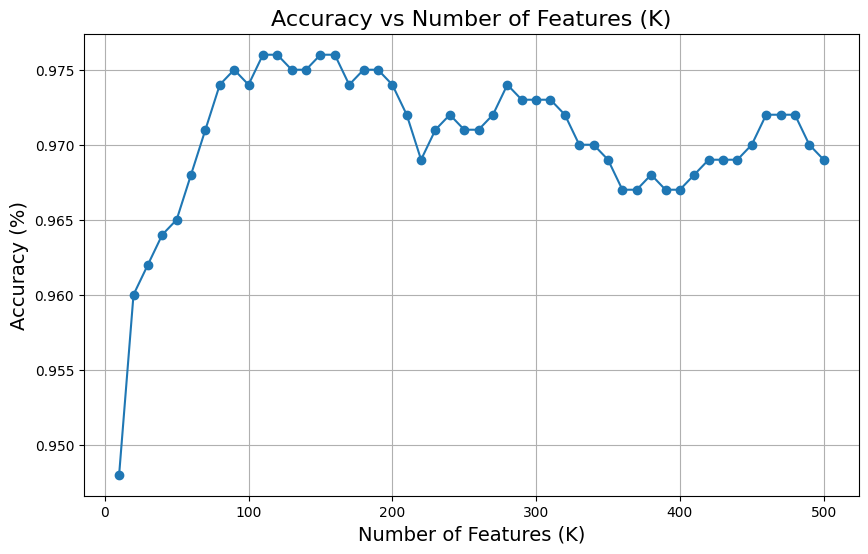

In [ ]:
#Optional section

# Calculate mutual information for all features
def calculate_mutual_information(pi_ham, pi_spam, theta_ham, theta_spam):
    """
    Calculate mutual information Ij for all features.
    """
    theta_j = pi_ham * theta_ham + pi_spam * theta_spam
    Ij_ham = pi_ham * (
        theta_ham * np.log((theta_ham + eps) / (theta_j + eps))
        + (1 - theta_ham) * np.log((1 - theta_ham + eps) / (1 - theta_j + eps))
    )
    Ij_spam = pi_spam * (
        theta_spam * np.log((theta_spam + eps) / (theta_j + eps))
        + (1 - theta_spam) * np.log((1 - theta_spam + eps) / (1 - theta_j + eps))
    )
    return Ij_ham + Ij_spam

mutual_information = calculate_mutual_information(pi_ham, pi_spam, theta_ham, theta_spam)


# Rank features by mutual information
top_features_idx = np.argsort(mutual_information)[::-1]  # Descending order

# Retain only the top K features
K = 100  # Number of top features to keep
top_K_features = top_features_idx[:K]

# Reduced test and train sets
X_train_reduced = X_train[:, top_K_features]
X_test_reduced = X_test[:, top_K_features]
theta_ham_reduced = theta_ham[top_K_features]
theta_spam_reduced = theta_spam[top_K_features]

# Recalculate MAP with reduced features
log_posterior_ham_reduced = calculate_log_posterior(X_test_reduced, pi_ham, theta_ham_reduced)
log_posterior_spam_reduced = calculate_log_posterior(X_test_reduced, pi_spam, theta_spam_reduced)
predictions_reduced_map = log_posterior_ham_reduced > log_posterior_spam_reduced
accuracy_reduced_map = np.mean(predictions_reduced_map == y_test)
print(f"Reduced MAP Accuracy with Top {K} Features: {accuracy_reduced_map * 100:.2f}%")


# Plot accuracy as a function of K
accuracies = []
K_values = list(range(10, 501, 10))  # Test for various values of K
for K in K_values:
    top_K_features = top_features_idx[:K]
    X_test_reduced = X_test[:, top_K_features]
    theta_ham_reduced = theta_ham[top_K_features]
    theta_spam_reduced = theta_spam[top_K_features]
    log_posterior_ham_reduced = calculate_log_posterior(X_test_reduced, pi_ham, theta_ham_reduced)
    log_posterior_spam_reduced = calculate_log_posterior(X_test_reduced, pi_spam, theta_spam_reduced)
    predictions_reduced_map = log_posterior_ham_reduced > log_posterior_spam_reduced
    accuracies.append(np.mean(predictions_reduced_map == y_test))

plt.figure(figsize=(10, 6))
plt.plot(K_values, accuracies, marker="o")
plt.xlabel("Number of Features (K)", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.title("Accuracy vs Number of Features (K)", fontsize=16)
plt.grid()
plt.show()


**Part 4 – Plotting the ROC curve**

For the discrete data classification problem of Part 3, analyse the performance of the classifier plotting the complete ROC curve, instead of simply measuring the accuracy. This requires to do the following.

*   Instead of classifying the documents choosing class 1 if $p(y=1|x)>p(y=2|x)$, now you can generalize this to choosing class 1 if $\frac{p(y=1|x)}{p(y=2|x)}>\tau \in [0, \infty)$ for some threshold $\tau$ that determines the compromise between true positive rate (TPR) and false positive rate (FPR).
*   Choose a **reasonable** range of values for $\tau$. For each value of $\tau$, compute the TPR and FPR on the dataset (Hint: determine suitable minimum and maximum values for $\tau$, and sample densely enough in that range).
* Plot a curve of TPR as a function of FPR – this is the ROC curve for this classifier.

*   Determine an estimate of the Equal Error Rate (EER), i.e. the point of the ROC curve such that TPR+FPR=1.

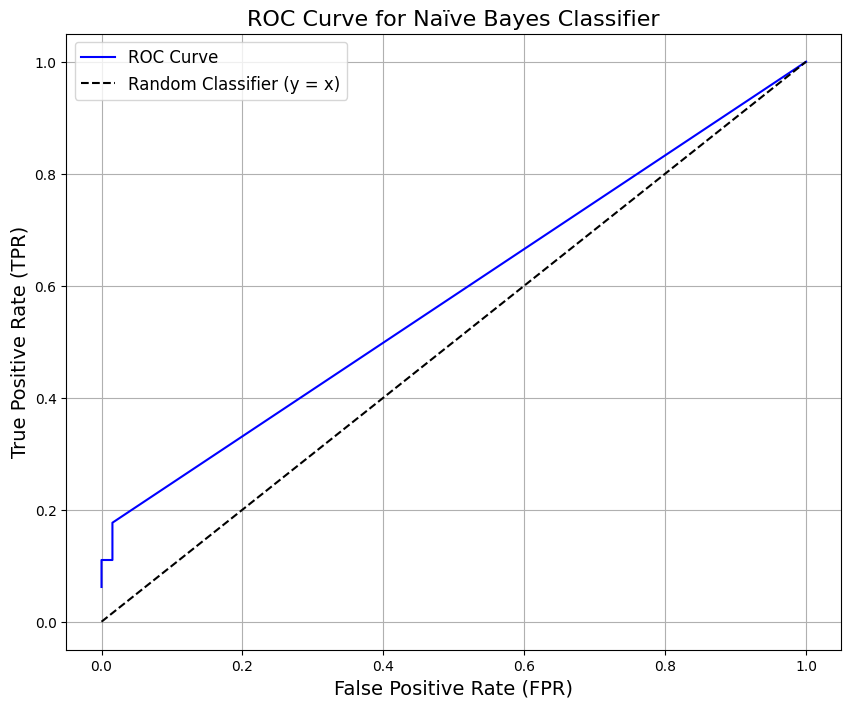

EER not found within the computed range.


In [ ]:

# Step 1: Calculate the posterior probabilities
# Use the posterior probabilities previously and classify using the formula above to estimate tau
log_posterior_ham = calculate_log_posterior(X_test, pi_ham, theta_ham)
log_posterior_spam = calculate_log_posterior(X_test, pi_spam, theta_spam)

posterior_ham = np.exp(log_posterior_ham)
posterior_spam = np.exp(log_posterior_spam)

# Step 2: Define the range of tau values
# Tau values determine the threshold for classifying as ham or spam
tau_values = np.linspace(0, 2, 1000)  # Range of tau (sampled densely)

# Step 3: Compute TPR and FPR for each tau
tpr_list = []
fpr_list = []

for tau in tau_values:
    # Predict class based on tau
    predictions = (posterior_ham / (posterior_spam + eps)) > tau

    # Note: To estimate the TPR you need to compute the number of cases where class 1 is correctly predicted,
    # this value then has to be divided by the number of elements in the test set which belong to class 1
    true_positives = np.sum((predictions == True) & (y_test == True))
    total_positives = np.sum(y_test == True)
    tpr = true_positives / total_positives if total_positives > 0 else 0

    # Note: The FPR is computed by selecting the number of cases where class 1 is predicted incorrectly,
    # this value then has to be divided by the number of elements in the test set which do not belong to class 1
    false_positives = np.sum((predictions == True) & (y_test == False))
    total_negatives = np.sum(y_test == False)
    fpr = false_positives / total_negatives if total_negatives > 0 else 0

    tpr_list.append(tpr)
    fpr_list.append(fpr)

# Step 4: Plot the ROC curve
# The point corresponding to the EER can be found by plotting on the ROC curve the function y = 1 - x
plt.figure(figsize=(10, 8))
plt.plot(fpr_list, tpr_list, label="ROC Curve", color="blue")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (y = x)")
plt.xlabel("False Positive Rate (FPR)", fontsize=14)
plt.ylabel("True Positive Rate (TPR)", fontsize=14)
plt.title("ROC Curve for Naïve Bayes Classifier", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()

# Step 5: Estimate the Equal Error Rate (EER)
# The point corresponding to the EER can be found by plotting on the ROC curve the function y = 1 - x
eer_thresholds = [(fpr, tpr) for fpr, tpr in zip(fpr_list, tpr_list) if np.isclose(fpr + tpr, 1, atol=0.01)]
if eer_thresholds:
    eer = min(eer_thresholds, key=lambda x: abs(x[0] - x[1]))
    print(f"Estimated Equal Error Rate (EER): FPR = {eer[0]:.4f}, TPR = {eer[1]:.4f}")
else:
    print("EER not found within the computed range.")


**Part 5 – Classification – continuous data**

This Part employs the Iris dataset already employed in Part 1, and performs model fitting and classification using several versions of **Gaussian discriminative analysis**. However, for this exercise the available data have to be divided into two sets, namely *training* and *test* data.

we will have to 1) re-fit the training data to the specific model (see below), 2) classify each of the test samples, and 3) calculate the accuracy of each classifier.

Classifiers to be employed:
*   Two-class quadratic discriminant analysis (fitting: both mean values and covariance matrices are class-specific – same as in exercise 1).
*   Two-class linear discriminant analysis (fitting: class-specific mean values as in the previous case. Shared covariance matrix is calculated putting together the elements of both classes; the mean values should also be recalculated accordingly).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Load the dataset
Dataset1 = h5py.File("/content/Lab2_Ex_1_Iris.hdf5")
Data = np.array(Dataset1.get('Dataset'))

# Split the dataset into training and test sets
Train = Data[:50, :]  # First 50 samples for training
Test = Data[50:, :]   # Remaining samples for testing

# Separate features and labels
X_train = Train[:, :2]  # Features: petal length and petal width
y_train = Train[:, 2]   # Labels
X_test = Test[:, :2]
y_test = Test[:, 2]

# Small constant to avoid numerical issues
eps = 1e-6

### **Two-class Quadratic Discriminant Analysis**
# Step 1: Fit the training data (calculate mean and covariance matrices)
mean_class0 = np.mean(X_train[y_train == 0], axis=0)
mean_class1 = np.mean(X_train[y_train == 1], axis=0)
cov_class0 = np.cov(X_train[y_train == 0], rowvar=False) + eps * np.eye(X_train.shape[1])
cov_class1 = np.cov(X_train[y_train == 1], rowvar=False) + eps * np.eye(X_train.shape[1])

# Step 2: Classify test samples using quadratic discriminant analysis
def quadratic_discriminant(x, mean, cov):
    inv_cov = np.linalg.inv(cov)
    diff = x - mean
    return -0.5 * np.log(np.linalg.det(cov)) - 0.5 * np.dot(np.dot(diff, inv_cov), diff.T)

y_pred_qda = []
for x in X_test:
    qda_score_class0 = quadratic_discriminant(x, mean_class0, cov_class0)
    qda_score_class1 = quadratic_discriminant(x, mean_class1, cov_class1)
    y_pred_qda.append(0 if qda_score_class0 > qda_score_class1 else 1)

accuracy_qda = np.mean(y_pred_qda == y_test)
print(f"Accuracy of Quadratic Discriminant Analysis: {accuracy_qda * 100:.2f}%")

### **Two-class Linear Discriminant Analysis**
# Step 1: Calculate shared covariance matrix
pooled_cov = np.cov(X_train, rowvar=False) + eps * np.eye(X_train.shape[1])

# Step 2: Classify test samples using linear discriminant analysis
def linear_discriminant(x, mean, cov):
    inv_cov = np.linalg.inv(cov)
    return np.dot(x, np.dot(inv_cov, mean)) - 0.5 * np.dot(mean, np.dot(inv_cov, mean))

y_pred_lda = []
for x in X_test:
    lda_score_class0 = linear_discriminant(x, mean_class0, pooled_cov)
    lda_score_class1 = linear_discriminant(x, mean_class1, pooled_cov)
    y_pred_lda.append(0 if lda_score_class0 > lda_score_class1 else 1)

accuracy_lda = np.mean(y_pred_lda == y_test)
print(f"Accuracy of Linear Discriminant Analysis: {accuracy_lda * 100:.2f}%")


Accuracy of Quadratic Discriminant Analysis: 94.00%
Accuracy of Linear Discriminant Analysis: 90.00%


**comments to Part 5**

The results indicate that Quadratic Discriminant Analysis (QDA) achieved a higher accuracy (94.00%) compared to Linear Discriminant Analysis (LDA) (90.00%) for this dataset. This suggests that the assumption of class-specific covariance matrices in QDA better captures the distribution of the data compared to the shared covariance assumption in LDA. However, the slightly lower accuracy of LDA may indicate that the shared covariance assumption is not entirely invalid, and LDA could be a simpler alternative when computational efficiency is prioritized or when the dataset size is smaller. Overall, QDA provides a more flexible and accurate model for this classification problem.

**Part 6 – Classification – continuous data**

Classify the data in the phoneme dataset from Lab. 1 using quadratic discriminant analysis, linear discriminat analysis and a Naive Bayes classifier.

Compute the accuracy of each classifier and compare its performance with that of the k-nn classifier developed in Lab. 1.

Note: in Lab1 we had to employ a subset of the oiginal dataset due to the fact that k-nn has a quadratic complexity making it unfit for use on large datasets. The algorithms illustrated in this Lab have smaller complexity and thus it is possible to train on more data.

For this Part we can use the sklearn library.

In [ ]:
import numpy as np
import h5py
from scipy.stats import multivariate_normal

Dataset2 = h5py.File("/content/Lab2_Ex_6_phoneme.hdf5")
Data = np.array(Dataset2.get('Dataset'))

Train = Data[:4000,:]
Test = Data[4000:,:]
len_dat = np.shape(Test)[0]

from sklearn import metrics
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

# Part 1: Linear Discriminant Analysis (LDA)
clf = LinearDiscriminantAnalysis()  # Initialize LDA model
clf.fit(Train[:, :-1], Train[:, -1])  # Train the model on training data
y_pred_lda = clf.predict(Test[:, :-1])  # Predict on test data
accuracy_lda = metrics.accuracy_score(Test[:, -1], y_pred_lda)  # Calculate accuracy
print(f"LDA Accuracy: {accuracy_lda * 100:.2f}%")

# Part 2: Quadratic Discriminant Analysis (QDA)
clf2 = QuadraticDiscriminantAnalysis()  # Initialize QDA model
clf2.fit(Train[:, :-1], Train[:, -1])  # Train the model on training data
y_pred_qda = clf2.predict(Test[:, :-1])  # Predict on test data
accuracy_qda = metrics.accuracy_score(Test[:, -1], y_pred_qda)  # Calculate accuracy
print(f"QDA Accuracy: {accuracy_qda * 100:.2f}%")

# Part 3: Gaussian Naive Bayes (GNB)
clf3 = GaussianNB()  # Initialize Naive Bayes model
clf3.fit(Train[:, :-1], Train[:, -1])  # Train the model on training data
y_pred_nb = clf3.predict(Test[:, :-1])  # Predict on test data
accuracy_nb = metrics.accuracy_score(Test[:, -1], y_pred_nb)  # Calculate accuracy
print(f"Naive Bayes Accuracy: {accuracy_nb * 100:.2f}%")

LDA Accuracy: 94.11%
QDA Accuracy: 88.80%
Naive Bayes Accuracy: 90.18%


**Comments to Part 6**

The results demonstrate that the Linear Discriminant Analysis (LDA) classifier achieved the highest accuracy (94.11%), outperforming both the Quadratic Discriminant Analysis (QDA) and Gaussian Naive Bayes (GNB) classifiers, which achieved 88.80% and 90.18% accuracy, respectively. This suggests that the assumption of a shared covariance matrix in LDA aligns well with the underlying structure of the data, providing a balance between simplicity and effectiveness. In contrast, QDA's class-specific covariance matrices might have overfitted the data, leading to slightly lower accuracy. Meanwhile, the Gaussian Naive Bayes classifier, despite its assumption of feature independence, performed reasonably well, indicating that the features in this dataset have low interdependence.

Overall, LDA emerged as the best classifier for this specific dataset.